# Teste de Algoritmos Alternativos

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split, cross_val_score, KFold, learning_curve
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler


from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.svm import SVR
from xgboost import XGBRegressor

# Configuração visual para padrão de artigo científico
sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 12})

## Carregamento dos Dados e Preparação

In [12]:
# Carregamento dos Dados
df = pd.read_csv('../data/raw/hepg2.csv')

X = df[['% DMSO', 'TREHALOSE']]
y = df['VIABILIDADE']

# Divisão de Treino e Teste (Corte único de 80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Normalização para a Rede Neural e para o SVR
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Escalonamento do dataset inteiro (necessário para a validação cruzada e curvas de aprendizado do MLP/SVR)
X_scaled = scaler.fit_transform(X)

# Validador cruzado padrão para que todos passem pelo mesmo teste
cv = KFold(n_splits=5, shuffle=True, random_state=42)

# Treinamento e Validação Cruzada (Todos os Modelos)

In [13]:
print("--- AVALIAÇÃO COM VALIDAÇÃO CRUZADA (5 FOLDS) ---")

# 1. Random Forest (Modelo Base)
rf_model = joblib.load('../random_forest_model.pkl')
y_pred_rf = rf_model.predict(X_test)
cv_rf = cross_val_score(rf_model, X, y, cv=cv, scoring='r2').mean()
print(f"Random Forest -> R² Teste: {r2_score(y_test, y_pred_rf):.4f} | R² Validação Cruzada: {cv_rf:.4f}")

# 2. Rede Neural Artificial (MLP)
mlp_model = MLPRegressor(hidden_layer_sizes=(64, 32), max_iter=2000, random_state=42, early_stopping=True)
mlp_model.fit(X_train_scaled, y_train)
y_pred_mlp = mlp_model.predict(X_test_scaled)
cv_mlp = cross_val_score(mlp_model, X_scaled, y, cv=cv, scoring='r2').mean()
print(f"Rede Neural   -> R² Teste: {r2_score(y_test, y_pred_mlp):.4f} | R² Validação Cruzada: {cv_mlp:.4f}")

# 3. Support Vector Regression (SVR)
svr_model = SVR(kernel='rbf', C=100, gamma=0.1)
svr_model.fit(X_train_scaled, y_train)
y_pred_svr = svr_model.predict(X_test_scaled)
cv_svr = cross_val_score(svr_model, X_scaled, y, cv=cv, scoring='r2').mean()
print(f"SVR           -> R² Teste: {r2_score(y_test, y_pred_svr):.4f} | R² Validação Cruzada: {cv_svr:.4f}")

# 4. XGBoost Regressor
xgb_model = XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)
cv_xgb = cross_val_score(xgb_model, X, y, cv=cv, scoring='r2').mean()
print(f"XGBoost       -> R² Teste: {r2_score(y_test, y_pred_xgb):.4f} | R² Validação Cruzada: {cv_xgb:.4f}")

--- AVALIAÇÃO COM VALIDAÇÃO CRUZADA (5 FOLDS) ---
Random Forest -> R² Teste: 0.9799 | R² Validação Cruzada: 0.9738


c:\Users\arthu\OneDrive\Área de Trabalho\hepato_cryo_ai\venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (2000) reached and the optimization hasn't converged yet.
  warnings.warn(


Rede Neural   -> R² Teste: 0.6122 | R² Validação Cruzada: 0.7576
SVR           -> R² Teste: 0.5441 | R² Validação Cruzada: 0.3351
XGBoost       -> R² Teste: 0.9773 | R² Validação Cruzada: 0.9731


# Curvas de Aprendizado

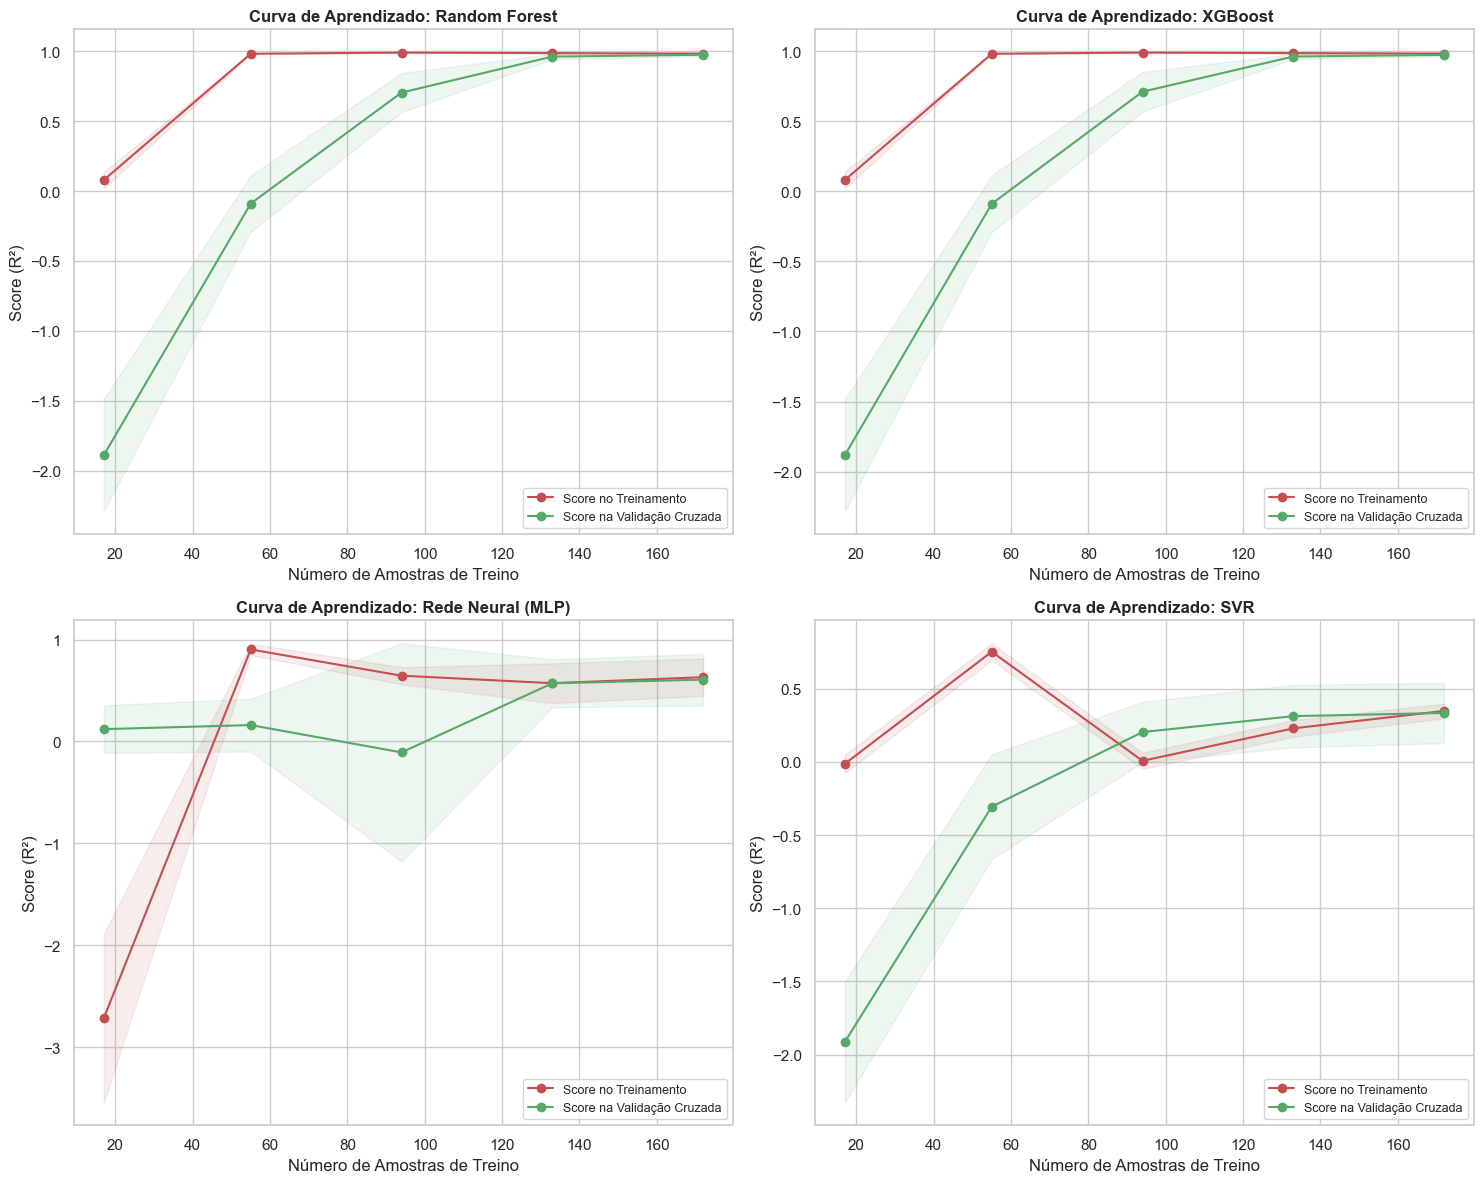

In [14]:
def plotar_curva_aprendizado(estimator, titulo, X_dados, y_dados, eixo):
    """Função utilitária para calcular e plotar a curva de aprendizado em um sub-gráfico."""
    train_sizes, train_scores, test_scores = learning_curve(
        estimator, X_dados, y_dados, cv=cv, n_jobs=-1, 
        train_sizes=np.linspace(0.1, 1.0, 5), scoring='r2'
    )
    
    # Médias e desvios
    train_scores_mean = np.mean(train_scores, axis=1)
    train_scores_std = np.std(train_scores, axis=1)
    test_scores_mean = np.mean(test_scores, axis=1)
    test_scores_std = np.std(test_scores, axis=1)

    eixo.set_title(titulo, fontweight='bold')
    eixo.set_xlabel("Número de Amostras de Treino")
    eixo.set_ylabel("Score (R²)")
    
    # Sombras de desvio padrão
    eixo.fill_between(train_sizes, train_scores_mean - train_scores_std,
                     train_scores_mean + train_scores_std, alpha=0.1, color="r")
    eixo.fill_between(train_sizes, test_scores_mean - test_scores_std,
                     test_scores_mean + test_scores_std, alpha=0.1, color="g")
    
    # Linhas principais
    eixo.plot(train_sizes, train_scores_mean, 'o-', color="r", label="Score no Treinamento")
    eixo.plot(train_sizes, test_scores_mean, 'o-', color="g", label="Score na Validação Cruzada")
    eixo.legend(loc="lower right", fontsize=9)

# Criando a figura com 4 quadros (2x2)
fig, ax = plt.subplots(2, 2, figsize=(15, 12))

# Plotando (Atenção para passar os dados normais para árvores e escalonados para SVR/MLP)
plotar_curva_aprendizado(rf_model, "Curva de Aprendizado: Random Forest", X, y, ax[0, 0])
plotar_curva_aprendizado(xgb_model, "Curva de Aprendizado: XGBoost", X, y, ax[0, 1])
plotar_curva_aprendizado(mlp_model, "Curva de Aprendizado: Rede Neural (MLP)", X_scaled, y, ax[1, 0])
plotar_curva_aprendizado(svr_model, "Curva de Aprendizado: SVR", X_scaled, y, ax[1, 1])

plt.tight_layout()
plt.savefig('curvas_de_aprendizado.png', dpi=300)
plt.show()

## Visualização Científica

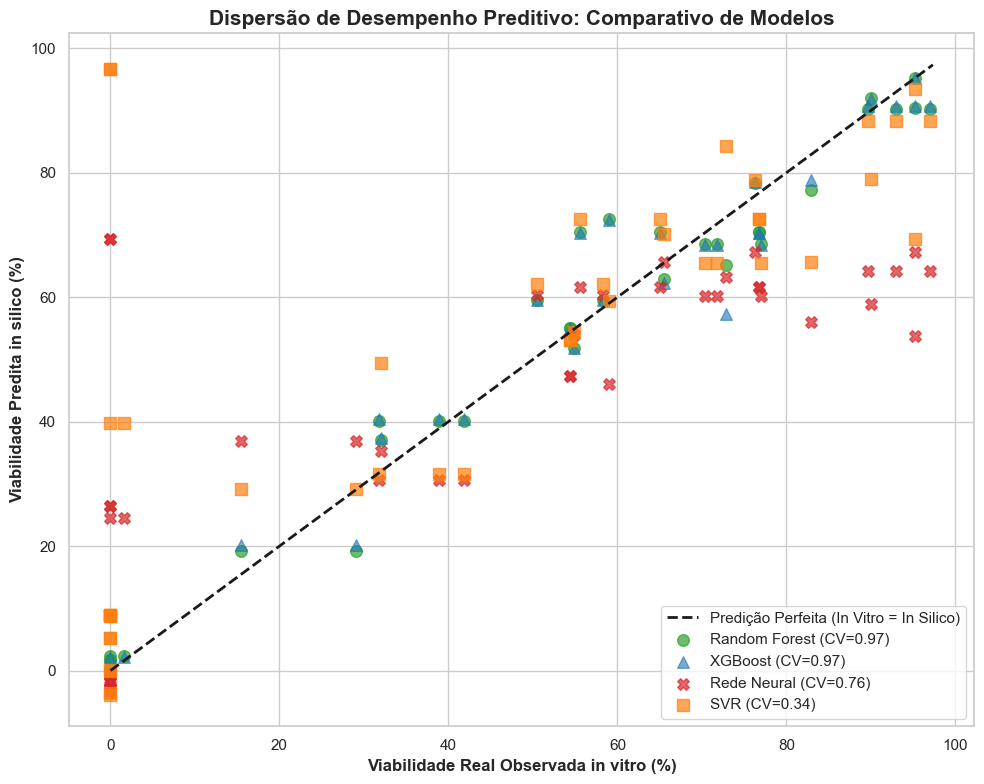

In [15]:
# Configurando o Gráfico Comparativo Geral
plt.figure(figsize=(10, 8))

# Linha Ideal (Predição Perfeita)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'k--', lw=2, label='Predição Perfeita (In Vitro = In Silico)')

# Plotando as famílias de Árvores (Modelos Robustos)
plt.scatter(y_test, y_pred_rf, alpha=0.7, color='#2ca02c', label=f'Random Forest (CV={cv_rf:.2f})', s=70)
plt.scatter(y_test, y_pred_xgb, alpha=0.6, color='#1f77b4', label=f'XGBoost (CV={cv_xgb:.2f})', s=70, marker='^')

# Plotando as famílias de Distância/Pesos (Modelos com Dificuldade nos Limites)
plt.scatter(y_test, y_pred_mlp, alpha=0.7, color='#d62728', label=f'Rede Neural (CV={cv_mlp:.2f})', s=70, marker='X')
plt.scatter(y_test, y_pred_svr, alpha=0.7, color='#ff7f0e', label=f'SVR (CV={cv_svr:.2f})', s=70, marker='s')

plt.xlabel('Viabilidade Real Observada in vitro (%)', fontweight='bold')
plt.ylabel('Viabilidade Predita in silico (%)', fontweight='bold')
plt.title('Dispersão de Desempenho Preditivo: Comparativo de Modelos', fontsize=15, fontweight='bold')
plt.legend()
plt.tight_layout()

plt.savefig('comparativo_dispersao_4_algoritmos.png', dpi=300)
plt.show()